In [1]:
import sys
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

sys.path.append(os.path.abspath('..'))

from src.config import TARGET_CLASSES, IMAGE_SIZE, BATCH_SIZE, GENERATE_COUNT_MAP
from src.utils.data_loader import ButterflyDataset
from src.utils.metrics import inception_score, frechet_inception_distance, mean_ssim

NUM_CLASSES = len(TARGET_CLASSES)   # número de classes condicionais
print(f"Classes: {TARGET_CLASSES}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Classes: ['AMERICAN SNOOT', 'CRIMSON PATCH', 'MALACHITE', 'GOLD BANDED', 'WOOD SATYR']
NUM_CLASSES: 5


In [2]:
path    = "splits"
img_dir = '../data/raw/train'
df      = pd.read_csv(os.path.join(path, 'full_train_split.csv'))

data_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),          # augmentação leve — ajuda o G
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],       # [0,1] → [-1, 1]  (alinha com Tanh)
                         [0.5, 0.5, 0.5]),
])

dataset    = ButterflyDataset(df=df, img_dir=img_dir,
                               transform=data_transform,
                               target_classes=None)
dataloader = data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset: {len(dataset)} imagens | {len(dataloader)} batches/época")


Dataset: 4159 imagens | 130 batches/época


In [3]:
full_train_df = pd.read_csv('splits/full_train_split.csv')
train_df = pd.read_csv('splits/train_split.csv')
val_df = pd.read_csv('splits/val_split.csv')
test_df = pd.read_csv('splits/test_split.csv')

train_dataset = ButterflyDataset(df=train_df, img_dir=img_dir, transform=data_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = ButterflyDataset(df=val_df, img_dir=img_dir, transform=data_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

full_train_dataset = ButterflyDataset(df=full_train_df, img_dir=img_dir, transform=data_transform)
full_train_dataloader = data.DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = ButterflyDataset(df=test_df, img_dir=img_dir, transform=data_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()       else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print("Device:", device)

Device: mps


# 1. Conditional AE

In [5]:
from src.ae.conditional_vae_1 import ConditionalVAE
from src.ae.conditional_vae_train import cvae_loss_function, train_cvae
from src.ae.conditional_vae_images import plot_cvae_losses, comparar_duas_classes, comparar_reais_vs_sinteticas
from src.ae.conditional_evaluate import evaluate


In [6]:
cvae_model = ConditionalVAE(img_channels=3, num_classes=75, latent_dim=128, img_size=IMAGE_SIZE)
cvae_model, cvae_history = train_cvae(
    model=cvae_model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    device=device,
    epochs=30,
    stop=5
)

hiperparametros_cvae = {
    "model_architecture": "ConditionalVAE",
    "latent_dim": 128,
}

Época 1/30 -> Train Loss: 4368.84 (BCE: 4268.29, KLD: 100.55) || Val Loss: 3312.50 (BCE: 3235.79, KLD: 76.71)
Época 2/30 -> Train Loss: 3234.10 (BCE: 3162.85, KLD: 71.25) || Val Loss: 3145.09 (BCE: 3079.62, KLD: 65.47)
Época 3/30 -> Train Loss: 3143.89 (BCE: 3078.03, KLD: 65.85) || Val Loss: 3095.86 (BCE: 3034.66, KLD: 61.20)
Época 4/30 -> Train Loss: 3079.96 (BCE: 3017.12, KLD: 62.84) || Val Loss: 3060.76 (BCE: 3000.14, KLD: 60.62)
Época 5/30 -> Train Loss: 3041.29 (BCE: 2979.59, KLD: 61.69) || Val Loss: 3019.45 (BCE: 2962.22, KLD: 57.22)
Época 6/30 -> Train Loss: 3014.99 (BCE: 2952.28, KLD: 62.71) || Val Loss: 3015.32 (BCE: 2947.11, KLD: 68.21)
Época 7/30 -> Train Loss: 2987.93 (BCE: 2925.44, KLD: 62.49) || Val Loss: 2980.21 (BCE: 2919.46, KLD: 60.76)
Época 8/30 -> Train Loss: 2979.93 (BCE: 2916.21, KLD: 63.72) || Val Loss: 2968.45 (BCE: 2901.47, KLD: 66.98)
Época 9/30 -> Train Loss: 2960.19 (BCE: 2895.22, KLD: 64.97) || Val Loss: 2952.32 (BCE: 2888.15, KLD: 64.16)
Época 10/30 -> Tra

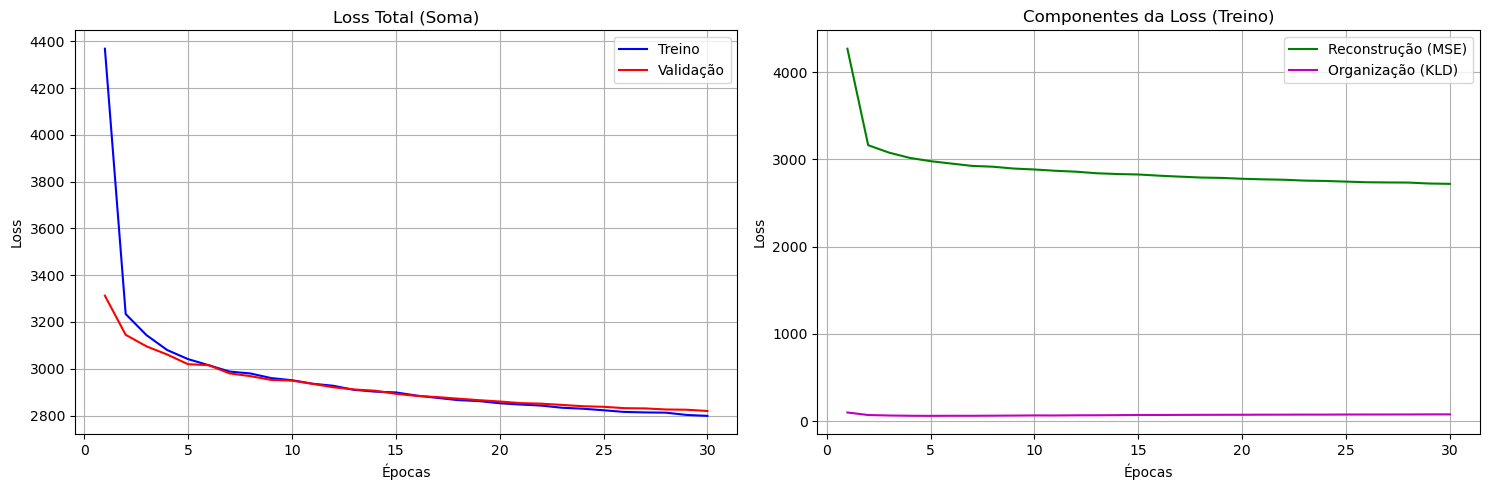

In [7]:
plot_cvae_losses(cvae_history, save=False)

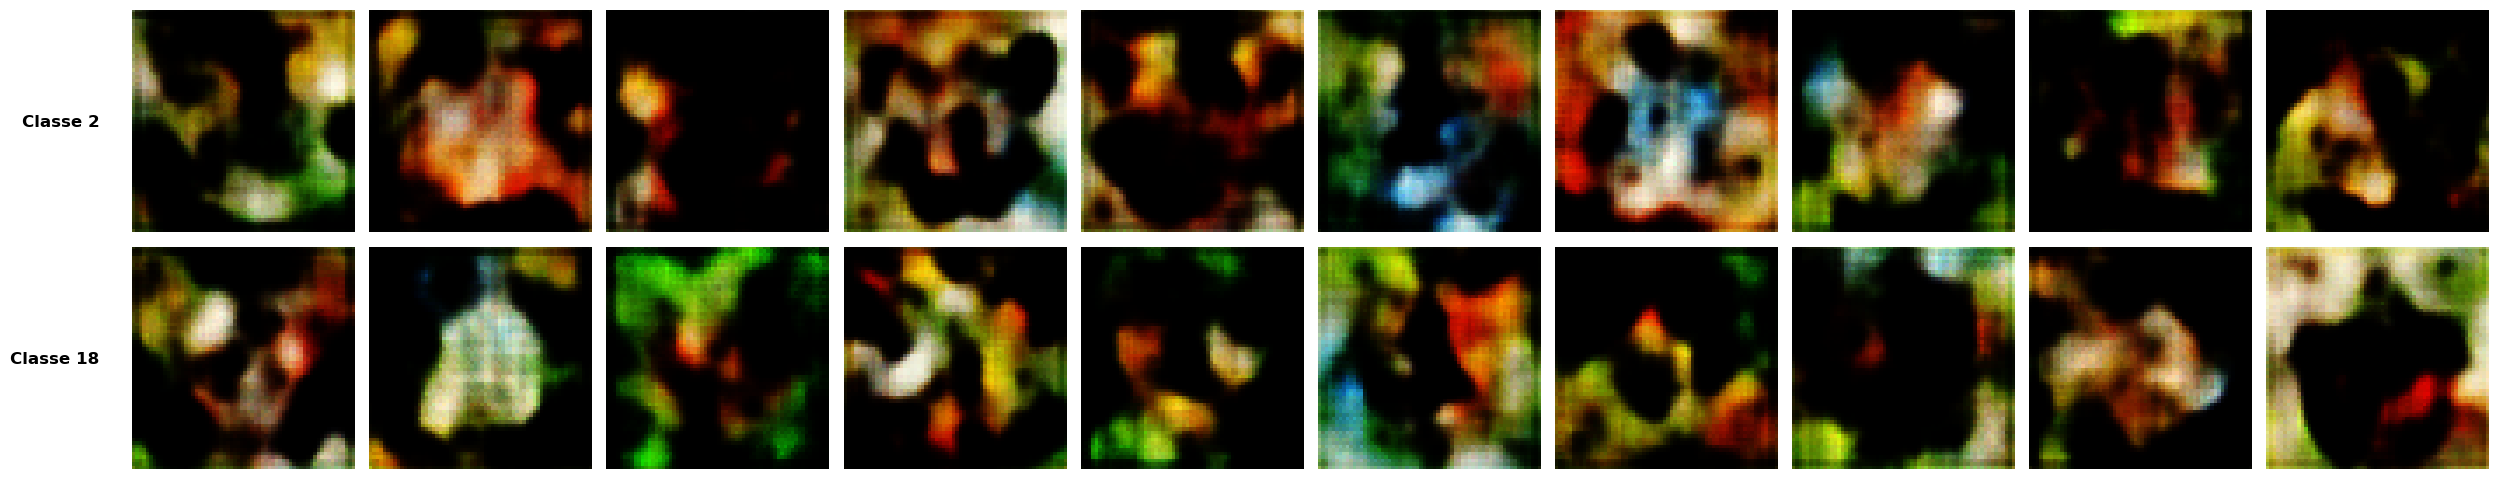

In [8]:
comparar_duas_classes(
    model=cvae_model, 
    device=device, 
    classe_A=2, 
    classe_B=18, 
    num_samples=10
)

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def comparar_reais_vs_sinteticas(model, device, dataloader, classe_A, classe_B, class_names=None):
    """
    Desenha uma grelha comparando Imagens Reais vs Sintéticas para duas classes.
    """
    model.eval()
    num_samples = 3 # 3 reais e 3 sintéticas por classe
    
    # 1. ANCORAR IMAGENS REAIS DO DATALOADER
    reais_A, reais_B = [], []
    
    # Varremos o dataloader para encontrar exemplos reais destas classes
    for inputs, labels in dataloader:
        for img, lbl in zip(inputs, labels):
            if lbl.item() == classe_A and len(reais_A) < num_samples:
                reais_A.append(img)
            elif lbl.item() == classe_B and len(reais_B) < num_samples:
                reais_B.append(img)
        if len(reais_A) == num_samples and len(reais_B) == num_samples:
            break

    # Converter listas de tensores para arrays NumPy [3, 64, 64, 3]
    reais_A = torch.stack(reais_A).cpu().permute(0, 2, 3, 1).numpy()
    reais_B = torch.stack(reais_B).cpu().permute(0, 2, 3, 1).numpy()

    # 2. GERAR IMAGENS SINTÉTICAS
    with torch.no_grad():
        sinteticas_A = model.generate_sample(device=device, label=classe_A, num_samples=num_samples)
        sinteticas_B = model.generate_sample(device=device, label=classe_B, num_samples=num_samples)
    
    sinteticas_A = sinteticas_A.cpu().permute(0, 2, 3, 1).numpy()
    sinteticas_B = sinteticas_B.cpu().permute(0, 2, 3, 1).numpy()

    # 3. CONFIGURAR A GRELHA (4 linhas: 2 para Classe A, 2 para Classe B)
    fig, axes = plt.subplots(4, num_samples, figsize=(9, 10))
    
    nome_A = class_names[classe_A] if class_names else f"Classe {classe_A}"
    nome_B = class_names[classe_B] if class_names else f"Classe {classe_B}"
    
    # Função interna rápida para normalizar o visual de cada imagem individualmente [0, 1]
    def norm_img(img):
        return (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Linha 0: Classe A Real | Linha 1: Classe A Sintética
    for i in range(num_samples):
        axes[0, i].imshow(norm_img(reais_A[i]))
        axes[1, i].imshow(norm_img(sinteticas_A[i]))
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].text(-10, 32, f"{nome_A}\n(REAIS)", fontsize=11, fontweight='bold', ha='right', va='center', color='blue')
    axes[1, 0].text(-10, 32, f"{nome_A}\n(CVAE)", fontsize=11, fontweight='bold', ha='right', va='center', color='green')

    # Linha 2: Classe B Real | Linha 3: Classe B Sintética
    for i in range(num_samples):
        axes[2, i].imshow(norm_img(reais_B[i]))
        axes[3, i].imshow(norm_img(sinteticas_B[i]))
        axes[2, i].axis('off')
        axes[3, i].axis('off')
    axes[2, 0].text(-10, 32, f"{nome_B}\n(REAIS)", fontsize=11, fontweight='bold', ha='right', va='center', color='blue')
    axes[3, 0].text(-10, 32, f"{nome_B}\n(CVAE)", fontsize=11, fontweight='bold', ha='right', va='center', color='green')

    plt.tight_layout()
    plt.show()

In [11]:
comparar_reais_vs_sinteticas(
    model=cvae_model,
    device=device,
    dataloader = train_dataloader
    classe_A=2,
    classe_B=18,
    num_samples = 3
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1491026412.py, line 4)

In [12]:
import torch
import numpy as np

def avaliar_modelo_gerativo(model, dataloader, device, num_imagens=256):
    """
    Recolhe imagens reais, gera imagens sintéticas correspondentes através do CVAE,
    aplica a normalização estrita para [0, 1] e calcula IS, FID e SSIM.
    """
    model.eval()
    
    list_reais = []
    list_sinteticas = []
    
    print(f"🔄 A recolher e a gerar {num_imagens} imagens para avaliação...")
    
    # 1. RECOLHER E GERAR OS DADOS
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Passar pelo modelo para obter a reconstrução correspondente
            reconstructed, _, _ = model(inputs, labels)
            
            for i in range(inputs.size(0)):
                if len(list_reais) >= num_imagens:
                    break
                    
                img_real = inputs[i].cpu()
                img_fake = reconstructed[i].cpu()
                
                # Regra de ouro: Garantir escala [0, 1] via normalização Min-Max individual
                img_real_norm = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)
                img_fake_norm = (img_fake - img_fake.min()) / (img_fake.max() - img_fake.min() + 1e-8)
                
                list_reais.append(img_real_norm)
                list_sinteticas.append(img_fake_norm)
                
            if len(list_reais) >= num_imagens:
                break

    print("📐 A calcular as métricas (isto pode demorar um bocado devido ao InceptionV3)...")
    
    # 2. CALCULAR INCEPTION SCORE (Usa as imagens sintéticas)
    is_mean, is_std = inception_score(list_sinteticas, batch_size=32, splits=4, device=device)
    
    # 3. CALCULAR FRECHET INCEPTION DISTANCE (Compara reais vs sintéticas)
    fid_value = frechet_inception_distance(list_reais, list_sinteticas, batch_size=32, device=device)
    
    # 4. CALCULAR STRUCTURAL SIMILARITY INDEX (SSIM)
    ssim_value = mean_ssim(list_reais, list_sinteticas)
    
    # 5. MOSTRAR RESULTADOS
    print("\n================ CARD DE MÉTRICAS DO CVAE ================")
    print(f"🎯 Inception Score (IS)                  : {is_mean:.4f} ± {is_std:.4f}  (Mais alto é melhor)")
    print(f"🖼️ Frechet Inception Distance (FID)       : {fid_value:.4f}          (Mais baixo é melhor)")
    print(f"🔬 Structural Similarity Index (SSIM)     : {ssim_value:.4f}          (Mais próximo de 1 é melhor)")
    print("==========================================================")
    
    return {"is_mean": is_mean, "fid": fid_value, "ssim": ssim_value}

In [13]:
resultados_metricas = evaluate(
    model=cvae_model,
    dataloader=val_dataloader, 
    device=device,
    num_imagens=2048
)

Generating images
Calculating metrics

================ CVAE Metrics ================
Inception Score (IS)                  : 3.5672 ± 0.0771  (Mais alto é melhor)
Frechet Inception Distance (FID)       : 235.2122          (Mais baixo é melhor)
Structural Similarity Index (SSIM)     : 0.1451          (Mais próximo de 1 é melhor)
